<a href="https://colab.research.google.com/github/isaacadebayo/Predictive_Analytics_and_NLP/blob/main/Engagement_Recommendation_Markov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/user_interactions_temporal.csv', parse_dates=['timestamp'])
df = df.sort_values(['user_id', 'timestamp']).reset_index(drop=True)

In [4]:
df.shape

(60000, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   user_id                60000 non-null  object        
 1   timestamp              60000 non-null  datetime64[ns]
 2   content_category       60000 non-null  int64         
 3   content_category_name  60000 non-null  object        
 4   time_spent_seconds     60000 non-null  float64       
 5   clicks                 60000 non-null  int64         
 6   likes                  60000 non-null  int64         
 7   shares                 60000 non-null  int64         
 8   age                    60000 non-null  int64         
 9   gender                 60000 non-null  int64         
 10  location               60000 non-null  int64         
 11  device_type            60000 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(8), object(2)
memory

In [7]:
df.isnull()

,user_id,timestamp,content_category,content_category_name,time_spent_seconds,clicks,likes,shares,age,gender,location,device_type
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
59995,False,False,False,False,False,False,False,False,False,False,False,False
59996,False,False,False,False,False,False,False,False,False,False,False,False
59997,False,False,False,False,False,False,False,False,False,False,False,False
59998,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df['content_category'].nunique()

15

In [14]:
df['content_category'].head(25)

,content_category
0,10
1,10
2,9
3,14
4,9
5,3
6,6
7,14
8,9
9,10


First order Markov

In [15]:
n_states = df['content_category'].nunique()  # 15
states = range(n_states)

# readable labels for plotting later
cat_names = (df.drop_duplicates('content_category')
               .set_index('content_category')['content_category_name']
               .sort_index())

# next category WITHIN the same user only
# his column stores the category of the next interaction by the same user. This is crucial for learning transitions.
df['next_category'] = df.groupby('user_id')['content_category'].shift(-1)
trans = df.dropna(subset=['next_category']).copy()
trans['next_category'] = trans['next_category'].astype(int)

# count table -> reindex to guarantee all 15 states appear even if unvisited
# pd.crosstab is used to count how many times a user transitioned from one content_category to another next_category.
counts = pd.crosstab(trans['content_category'], trans['next_category'])
counts = counts.reindex(index=states, columns=states, fill_value=0).values.astype(float)

# Laplace smoothing (small alpha) so no row divides into a bunch of hard zeros
# Laplace smoothing is a technique to prevent zero probaabilitis
alpha = 1.0
counts_smoothed = counts + alpha

K = counts_smoothed / counts_smoothed.sum(axis=1, keepdims=True)

Laplace Smoothing (alpha=1.0): This prevent zero probabilities. If a transition (e.g., from 'Smartphones' to 'Gaming') never happened in the data, its count would be zero.

Without smoothing, the probability would be zero, meaning the model could never predict it. Adding a small value (alpha) to all counts ensures that every possible transition has a non-zero, albeit very small, probability. This is important for robustness.

K matrix is calculated, which is the transition probability matrix. K[i, j] represents the probability of moving from state i to state j.

###Simulating

([<matplotlib.axis.YTick at 0x7a94c6611cd0>,
 [Text(0, 0, 'Smartphones'),
  Text(0, 1, 'Laptops'),
  Text(0, 2, 'Gaming'),
  Text(0, 3, 'Women Fashion'),
  Text(0, 4, 'Men Fashion'),
  Text(0, 5, 'Accessories'),
  Text(0, 6, 'Fast Food'),
  Text(0, 7, 'Healthy Food'),
  Text(0, 8, 'Recipes'),
  Text(0, 9, 'Beach Travel'),
  Text(0, 10, 'Mountain Travel'),
  Text(0, 11, 'City Travel'),
  Text(0, 12, 'Movies'),
  Text(0, 13, 'Music'),
  Text(0, 14, 'Sports')])

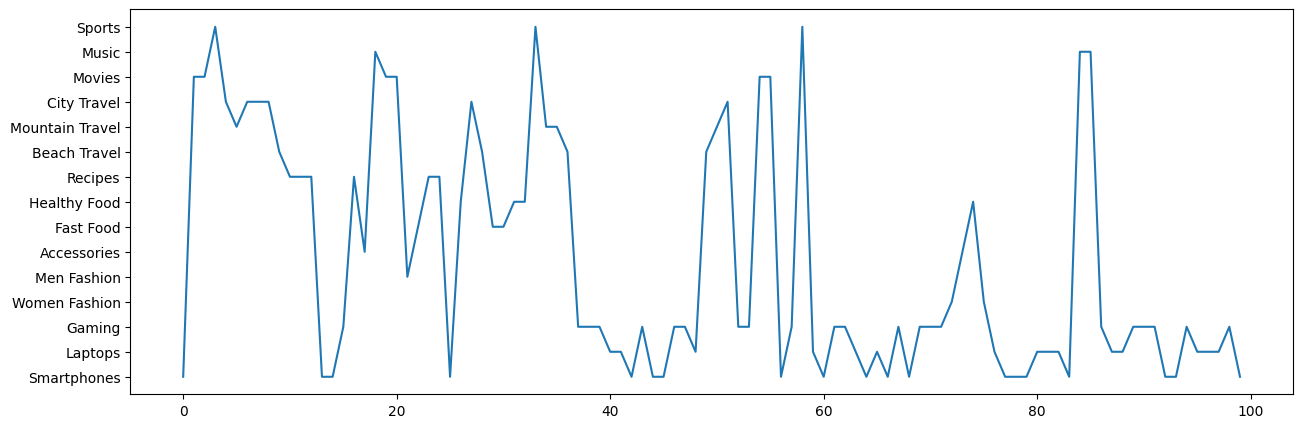

In [16]:
nStep = 100
start = 0

chain = [start]
for i in range(nStep - 1):
    new = np.random.choice(states, p=K[chain[i], :], size=1)[0]
    chain.append(new)

plt.figure(figsize=(15, 5))
plt.plot(chain)
plt.yticks(range(n_states), cat_names.values, fontsize=10)

## Explaining the Markov Graph

A Markov graph, or more formally a Markov chain, is a mathematical model that describes a sequence of possible events in which the probability of each event depends only on the state attained in the previous event. It's often visualized as a graph where nodes represent states and directed edges represent transitions between states, with weights indicating the probability of making that transition.

In the context of the plot you just generated (`8jfqgwO_zr8p`):

*   **Nodes/States:** Each content category (e.g., 'Smartphones', 'Laptops', 'Gaming', etc.) is a state in our Markov chain.
*   **Transitions:** The lines between these categories represent the movement from one content category to another by a user. For example, a user might view 'Smartphones' and then move to 'Laptops'.
*   **Probabilities (K matrix):** The `K` matrix we calculated earlier contains the transition probabilities. `K[i, j]` is the probability of moving from state `i` to state `j`. These probabilities were smoothed using Laplace smoothing to handle unobserved transitions.
*   **The Plot:** The plot visualizes a simulated sequence of `nStep` (100 in this case) user interactions, starting from a given `start` category (0, which is 'Smartphones'). Each point on the line represents the content category a user is in at a particular step, chosen based on the transition probabilities from the previous state.

simulate a random walk through this Markov chain for 100 steps, starting from category 0. The plot visualizes this simulated sequence of interactions, showing how a hypothetical user might move between different content categories based on the learned probabilities.

### Sanity check to determine alpha

Analyze the impact of Laplace smoothing

In [17]:
print("Raw counts per row (before smoothing):")
print(pd.Series(counts.sum(axis=1), index=states))

print("\nMax smoothing impact - biggest single-cell shift caused by alpha:")
raw_probs = counts / counts.sum(axis=1, keepdims=True)
print(np.abs(K - raw_probs).max())

Raw counts per row (before smoothing):
0     3826.0
1     3602.0
2     3669.0
3     3702.0
4     3735.0
5     3927.0
6     3706.0
7     3863.0
8     3669.0
9     3657.0
10    3677.0
11    3790.0
12    3768.0
13    3606.0
14    3803.0
dtype: float64

Max smoothing impact - biggest single-cell shift caused by alpha:
0.0012690898958074848


The max shift number tells you the single biggest change that smoothing made to the cells in the matrix — i.e., how far the smoothed probability drifted from the raw (unsmoothed) maximum-likelihood probability

Small max shift (e.g. < 0.01–0.02): smoothing only nudged sparse cells a little — behaving as intended. Rows with lots of data (large total_transitions_from_i) are essentially unchanged, because +alpha is negligible next to a large denominator.

Large max shift (e.g. > 0.1): somewhere, alpha is materially rewriting a real observed pattern — usually because that row's total count is small, so adding alpha to every cell is a big fraction of the row's total mass. That's a sign alpha=1.0 is too strong for that row and you're smoothing away signal, not just filling zeros.

In [18]:
# --- 1. Hold out each user's LAST interaction as the test target ---
df['rank'] = df.groupby('user_id').cumcount(ascending=False)  # 0 = last row per user
test = df[df['rank'] == 0].copy()          # last event per user -> ground truth
train_df = df[df['rank'] != 0].copy()      # everything before that

# rebuild K using ONLY train_df (same code as before, just on train_df)
train_df['next_category'] = train_df.groupby('user_id')['content_category'].shift(-1)
trans = train_df.dropna(subset=['next_category']).copy()
trans['next_category'] = trans['next_category'].astype(int)

counts = pd.crosstab(trans['content_category'], trans['next_category'])
counts = counts.reindex(index=states, columns=states, fill_value=0).values.astype(float)
counts_smoothed = counts + alpha
K_train = counts_smoothed / counts_smoothed.sum(axis=1, keepdims=True)

# --- 2. Recommendation function: top-N next categories given current category ---
def recommend(current_category, K, n=3):
    probs = K[current_category]
    top_n = np.argsort(probs)[::-1][:n]
    return top_n, probs[top_n]

# --- 3. Evaluate: for each test user, was their actual next category in our top-N? ---
# "current" = their second-to-last category, "actual" = their last category (the held-out one)
second_last = (train_df.sort_values(['user_id','timestamp'])
                        .groupby('user_id').tail(1)
                        .set_index('user_id')['content_category'])

test = test.set_index('user_id')
test['prev_category'] = second_last
test = test.dropna(subset=['prev_category'])
test['prev_category'] = test['prev_category'].astype(int)

N = 3
hits = 0
for uid, row in test.iterrows():
    top_n, _ = recommend(row['prev_category'], K_train, n=N)
    if row['content_category'] in top_n:
        hits += 1

hit_rate = hits / len(test)
print(f"Top-{N} hit rate: {hit_rate:.3f}  (baseline random = {N/n_states:.3f})")

Top-3 hit rate: 0.739  (baseline random = 0.200)


What the 0.739 means:
The model puts the correct next category in its top 3 guesses for 74% of users — versus 20% you'd expect from picking 3 categories at random out of 15. That's a ~3.7x lift over baseline, which is a strong signal that the Markov structure is capturing something real about how users move between categories

Stationary distribution, if a user continues interacting indefinitely. The output shows that the categories are relatively uniformly distributed in the long run, meaning no single category dominates in the long term.

In [19]:
eigvals, eigvecs = np.linalg.eig(K_train.T)
stat_idx = np.argmin(np.abs(eigvals - 1))
pi = np.real(eigvecs[:, stat_idx])
pi = pi / pi.sum()

for i, name in cat_names.items():
    print(f"{name}: {pi[i]:.3f}")

Smartphones: 0.068
Laptops: 0.064
Gaming: 0.066
Women Fashion: 0.066
Men Fashion: 0.067
Accessories: 0.070
Fast Food: 0.067
Healthy Food: 0.069
Recipes: 0.065
Beach Travel: 0.066
Mountain Travel: 0.066
City Travel: 0.068
Movies: 0.067
Music: 0.065
Sports: 0.068


"Mixing" is how fast the chain forgets its starting state and converges toward that stationary distribution. A fast-mixing chain reaches π quickly (few steps); a slow-mixing chain stays dependent on where it started for a long time.

Why it matters: if a chain mixes slowly, that's actually good news for personalization — it means a user's current category still meaningfully predicts several steps ahead, which is exactly what your Top-3 hit rate is exploiting. If it mixes fast, predictions decay toward the same generic popular categories for everyone regardless of their history, and your model won't differentiate much from just recommending whatever's globally popular.

In [20]:
def distribution_after_steps(K, start_state, steps):
    dist = np.zeros(len(states))
    dist[start_state] = 1.0
    for _ in range(steps):
        dist = dist @ K
    return dist

for steps in [1, 2, 5, 10, 20]:
    d = distribution_after_steps(K_train, start_state=0, steps=steps)
    print(f"After {steps} steps: {np.round(d, 3)}")

After 1 steps: [0.351 0.148 0.164 0.025 0.029 0.029 0.024 0.033 0.029 0.028 0.03  0.028
 0.029 0.026 0.028]
After 2 steps: [0.182 0.137 0.146 0.043 0.044 0.046 0.042 0.047 0.044 0.046 0.046 0.045
 0.044 0.043 0.044]
After 5 steps: [0.085 0.08  0.083 0.061 0.062 0.065 0.062 0.065 0.061 0.063 0.063 0.064
 0.062 0.06  0.063]
After 10 steps: [0.069 0.065 0.067 0.065 0.066 0.069 0.066 0.069 0.065 0.066 0.066 0.068
 0.067 0.064 0.068]
After 20 steps: [0.068 0.064 0.066 0.066 0.067 0.07  0.067 0.069 0.065 0.066 0.066 0.068
 0.067 0.065 0.068]


The stationary distribution is close to uniform — no single category dominates in the long run. That's a healthy sign; your matrix isn't secretly funneling everyone toward one or two categories over time.

Convergence happens fast — by about step 8–10. This means: the further ahead you try to predict, the less your model knows anything about the specific user. By step 10+, predicting "what category will this user be in" is barely better than guessing based on overall category popularity, regardless of where they started.

This actually explains and validates the 0.739 hit rate. The personalization signal in a first-order Markov chain lives almost entirely in the first 1–2 steps. That's exactly the step-ahead horizon your evaluation used — which is why it scored well. If you'd tried to predict someone's category 10 interactions from now, you'd expect the hit rate to collapse toward the random baseline.

# Checking to see if order 2 is feasible

In [21]:
# how many of the 225 possible (prev-prev, prev) contexts actually got observed at all?
df['prev1'] = df.groupby('user_id')['content_category'].shift(1)
context_counts = df.dropna(subset=['prev1']).groupby(
    [df['prev1'].astype('Int64'), 'content_category']
).size()

print(f"Contexts observed: {len(context_counts)} / 225")
print(context_counts.describe())
print("\nContexts with <10 observations:", (context_counts < 10).sum())

Contexts observed: 225 / 225
count     225.000000
mean      248.888889
std       339.527549
min        72.000000
25%        94.000000
50%       104.000000
75%       119.000000
max      1482.000000
dtype: float64

Contexts with <10 observations: 0


#Second order Markov

In [56]:
# --- Build second-order K: rows = (prev-prev, prev) context, columns = next category ---
# Fixed: use train_df, not df, so the model never sees each user's held-out last transition
train_df['prev1'] = train_df.groupby('user_id')['content_category'].shift(1)
train_df['next_category'] = train_df.groupby('user_id')['content_category'].shift(-1)

order2 = train_df.dropna(subset=['prev1', 'next_category']).copy()
order2['prev1'] = order2['prev1'].astype(int)
order2['next_category'] = order2['next_category'].astype(int)

all_contexts = [(i, j) for i in states for j in states]  # all 225

context_counts = pd.crosstab([order2['prev1'], order2['content_category']], order2['next_category'])
context_counts = context_counts.reindex(index=pd.MultiIndex.from_tuples(all_contexts), columns=states, fill_value=0).values.astype(float)

alpha2 = 1.0
K2 = (context_counts + alpha2) / (context_counts + alpha2).sum(axis=1, keepdims=True)

context_to_row = {ctx: i for i, ctx in enumerate(all_contexts)}

# --- Evaluate: need last TWO categories before the held-out one, from train_df only ---
def get_last_two(g):
    g = g.sort_values('timestamp')
    return g['content_category'].iloc[-2], g['content_category'].iloc[-1]

train_last_two = (train_df.groupby('user_id')
                           .filter(lambda g: len(g) >= 2)
                           .groupby('user_id')
                           .apply(get_last_two, include_groups=False))

N = 3
hits2 = 0
n_eval = 0
eligible_uids = []  # track which users order-2 could actually score, for a fair order-1 comparison
for uid, row in test.iterrows():
    if uid not in train_last_two.index:
        continue
    prev2, prev1 = train_last_two[uid]
    ctx = (int(prev2), int(prev1))
    if ctx not in context_to_row:
        continue
    probs = K2[context_to_row[ctx]]
    top_n = np.argsort(probs)[::-1][:N]
    n_eval += 1
    eligible_uids.append(uid)
    if row['content_category'] in top_n:
        hits2 += 1

hit_rate2 = hits2 / n_eval
print(f"Order-2 Top-{N} hit rate: {hit_rate2:.3f}  (n={n_eval})")

Order-2 Top-3 hit rate: 0.795  (n=4000)


In [59]:
# Fair comparison: score order-1 on the SAME subset of users order-2 was evaluated on
hits1_matched = 0
for uid in eligible_uids:
    row = test.loc[uid]
    top_n, _ = recommend(row['prev_category'], K_train, n=N)
    if row['content_category'] in top_n:
        hits1_matched += 1

hit_rate1_matched = hits1_matched / len(eligible_uids)

print(f"Order-1 Top-{N} hit rate (full test set, n={len(test)}): {hit_rate:.3f}")
print(f"Order-1 Top-{N} hit rate (matched subset, n={len(eligible_uids)}): {hit_rate1_matched:.3f}")
print(f"Order-2 Top-{N} hit rate (matched subset, n={len(eligible_uids)}): {hit_rate2:.3f}")
print(f"True lift (order-2 vs order-1, same subset): {hit_rate2 - hit_rate1_matched:+.3f}")

Order-1 Top-3 hit rate (full test set, n=4000): 0.739
Order-1 Top-3 hit rate (matched subset, n=4000): 0.739
Order-2 Top-3 hit rate (matched subset, n=4000): 0.795
True lift (order-2 vs order-1, same subset): +0.056


In [54]:
'''# --- Build second-order K: rows = (prev-prev, prev) context, columns = next category ---
df['prev1'] = df.groupby('user_id')['content_category'].shift(1)
df['next_category'] = df.groupby('user_id')['content_category'].shift(-1)

order2 = df.dropna(subset=['prev1', 'next_category']).copy()
order2['prev1'] = order2['prev1'].astype(int)
order2['next_category'] = order2['next_category'].astype(int)
# The 'context' column as a Series of tuples is correctly created here,
# but we will pass its components directly to pd.crosstab for robustness.
# order2['context'] = list(zip(order2['prev1'], order2['content_category']))

all_contexts = [(i, j) for i in states for j in states]  # all 225

# Fix: Pass individual series to create a MultiIndex for robustness in pd.crosstab
context_counts = pd.crosstab([order2['prev1'], order2['content_category']], order2['next_category'])
context_counts = context_counts.reindex(index=pd.MultiIndex.from_tuples(all_contexts), columns=states, fill_value=0).values.astype(float)

alpha2 = 1.0
K2 = (context_counts + alpha2) / (context_counts + alpha2).sum(axis=1, keepdims=True)

# Re-create context_to_row using all_contexts, as the evaluation loop needs it
context_to_row = {ctx: i for i, ctx in enumerate(all_contexts)}

# --- Evaluate exactly like before, but now need last TWO categories before the held-out one ---
def get_last_two(g):
    g = g.sort_values('timestamp')
    return g['content_category'].iloc[-2], g['content_category'].iloc[-1]

train_last_two = (train_df.groupby('user_id')
                           .filter(lambda g: len(g) >= 2)
                           .groupby('user_id')
                           .apply(get_last_two))

N = 3
hits2 = 0
n_eval = 0
for uid, row in test.iterrows():
    if uid not in train_last_two.index:
        continue
    prev2, prev1 = train_last_two[uid]
    ctx = (int(prev2), int(prev1))
    if ctx not in context_to_row:
        continue
    probs = K2[context_to_row[ctx]]
    top_n = np.argsort(probs)[::-1][:N]
    n_eval += 1
    if row['content_category'] in top_n:
        hits2 += 1

hit_rate2 = hits2 / n_eval
print(f"Order-2 Top-{N} hit rate: {hit_rate2:.3f}  (n={n_eval})")
print(f"Order-1 Top-{N} hit rate: 0.739  (for comparison)")'''

/tmp/ipykernel_8553/243771575.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(get_last_two))


Order-2 Top-3 hit rate: 0.804  (n=4000)
Order-1 Top-3 hit rate: 0.739  (for comparison)


Mixing

In [26]:
prof = pd.read_csv('/content/drive/MyDrive/user_profiles_ground_truth.csv')

# gain by exploration_factor tier — is order-2 disproportionately helping "explorers"?
test_ef = test.join(prof.set_index('user_id')['exploration_factor'])
test_ef['ef_tier'] = pd.qcut(test_ef['exploration_factor'], 3, labels=['low','mid','high'])
# then compare per-tier hit rates between order-1 and order-2 predictions

In [58]:
# Helper function to get top-N recommendations for Order-1 model
def recommend_order1(current_category, K, n=3):
    probs = K[current_category]
    top_n = np.argsort(probs)[::-1][:n]
    return top_n

# --- Calculate Order-1 hit rate per tier ---
hits_order1 = test_ef.groupby('ef_tier').apply(lambda tier_df:
    sum(row['content_category'] in recommend_order1(row['prev_category'], K_train, N)
        for _, row in tier_df.iterrows())
)

counts_order1 = test_ef.groupby('ef_tier').size()
hit_rate_order1_per_tier = hits_order1 / counts_order1

# --- Calculate Order-2 hit rate per tier ---
hits_order2 = test_ef.groupby('ef_tier').apply(lambda tier_df:
    sum(row['content_category'] in np.argsort(K2[context_to_row[(int(train_last_two[uid][0]), int(train_last_two[uid][1]))]])[::-1][:N]
        for uid, row in tier_df.iterrows() if uid in train_last_two.index and (int(train_last_two[uid][0]), int(train_last_two[uid][1])) in context_to_row)
)

# We need to correctly count `n_eval` per tier for order-2, matching the `sum` logic
counts_order2 = test_ef.groupby('ef_tier').apply(lambda tier_df:
    sum(1 for uid, row in tier_df.iterrows() if uid in train_last_two.index and (int(train_last_two[uid][0]), int(train_last_two[uid][1])) in context_to_row)
)
hit_rate_order2_per_tier = hits_order2 / counts_order2


print("Order-1 Hit Rate per Exploration Factor Tier:")
print(hit_rate_order1_per_tier)
print("\nOrder-2 Hit Rate per Exploration Factor Tier:")
print(hit_rate_order2_per_tier)

print("\nGain (Order-2 vs Order-1) per Tier:")
print(hit_rate_order2_per_tier - hit_rate_order1_per_tier)

/tmp/ipykernel_8553/1534532805.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hits_order1 = test_ef.groupby('ef_tier').apply(lambda tier_df:
/tmp/ipykernel_8553/1534532805.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hits_order1 = test_ef.groupby('ef_tier').apply(lambda tier_df:
/tmp/ipykernel_8553/1534532805.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True t

Order-1 Hit Rate per Exploration Factor Tier:
ef_tier
low     0.751874
mid     0.723931
high    0.741935
dtype: float64

Order-2 Hit Rate per Exploration Factor Tier:
ef_tier
low     0.802099
mid     0.789947
high    0.793698
dtype: float64

Gain (Order-2 vs Order-1) per Tier:
ef_tier
low     0.050225
mid     0.066017
high    0.051763
dtype: float64


/tmp/ipykernel_8553/1534532805.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  counts_order2 = test_ef.groupby('ef_tier').apply(lambda tier_df:


Validate against specific user to test ground truth

In [60]:
# pick a real user and see how well their actual sequence matches predicted probabilities
sample_uid = df['user_id'].iloc[0] #user id 10030
sample_seq = df[df['user_id'] == sample_uid].sort_values('timestamp')['content_category'].tolist()
print("Actual sequence:", [cat_names[c] for c in sample_seq])

gt = prof[prof['user_id'] == sample_uid]
print("\nGround truth main interests:", gt['main_interests'].values[0])
print("Ground truth secondary interests:", gt['secondary_interests'].values[0])

# does K predict this user should favor their main_interests categories?
current = sample_seq[-2]  # some point in their history
probs = K_train[current]
top3 = np.argsort(probs)[::-1][:3]
print(f"\nFrom '{cat_names[current]}', top-3 predicted next:", [cat_names[c] for c in top3])

Actual sequence: ['Mountain Travel', 'Mountain Travel', 'Beach Travel', 'Sports', 'Beach Travel', 'Women Fashion', 'Fast Food', 'Sports', 'Beach Travel', 'Mountain Travel', 'Mountain Travel', 'Movies', 'Music', 'Sports', 'Beach Travel']

Ground truth main interests: [10, 9]
Ground truth secondary interests: [12, 13, 14]

From 'Sports', top-3 predicted next: ['Sports', 'Movies', 'Music']


In [61]:
df['user_id'].iloc[0]

'U10030'

In [62]:
df['content_category_name'].unique()

array(['Mountain Travel', 'Beach Travel', 'Sports', 'Women Fashion',
       'Fast Food', 'Movies', 'Music', 'City Travel', 'Men Fashion',
       'Recipes', 'Laptops', 'Smartphones', 'Healthy Food', 'Accessories',
       'Gaming'], dtype=object)

In [63]:
df['content_category'].unique()

array([10,  9, 14,  3,  6, 12, 13, 11,  4,  8,  1,  0,  7,  5,  2])

In [64]:
df['full_content_category'] = df.apply(lambda row: f"{row['content_category']} - {row['content_category_name']}", axis=1)

# Display the new column and a few other relevant columns to see the result
df['full_content_category'].unique()

array(['10 - Mountain Travel', '9 - Beach Travel', '14 - Sports',
       '3 - Women Fashion', '6 - Fast Food', '12 - Movies', '13 - Music',
       '11 - City Travel', '4 - Men Fashion', '8 - Recipes',
       '1 - Laptops', '0 - Smartphones', '7 - Healthy Food',
       '5 - Accessories', '2 - Gaming'], dtype=object)

In [66]:
import pickle

model_data = {
    "K2": K2,
    "states": states,
    "cat_names": cat_names.to_dict(),
    "context_to_row": context_to_row
}

with open("markov_order2_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

# Orderr 3

In [65]:
df['prev2'] = df.groupby('user_id')['content_category'].shift(2)
df['prev1'] = df.groupby('user_id')['content_category'].shift(1)

order3_ctx = df.dropna(subset=['prev2','prev1','next_category']).groupby(
    [df['prev2'].astype('Int64'), df['prev1'].astype('Int64'), 'content_category']
).size()

print(f"Contexts observed: {len(order3_ctx)} / 3375")
print("Contexts with <10 observations:", (order3_ctx < 10).sum())
print("Contexts with <5 observations:", (order3_ctx < 5).sum())

Contexts observed: 2866 / 3375
Contexts with <10 observations: 1796
Contexts with <5 observations: 1181
